# PS0 — Dense Orbit Catalogue
## Option C: HH Delay-Directed Orbit Selection
### HHSMC Project — Corrected Pipeline — February 2026

**Purpose:** Build comprehensive catalogue of all stable periodic orbits accessible via (K, τ) parameter switching at fixed I_bias.

**Prerequisite:** ExpF0v3 → Gate G0 FAILED → Track B (Option C)
- Strong chaos found (λ₁ up to 0.218 ms⁻¹) but only 2–4 ISI clusters
- 75.1% periodic (5,711/7,600 pts) is the opportunity

**Gate PS-G0:** ≥15 distinct orbit types, ≥3 qualitative categories

## CELL 1 — Setup and Imports

In [ ]:
import numpy as np
from numba import njit
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap
import json, os, time, warnings
from datetime import datetime
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.spatial.distance import pdist, squareform
from collections import Counter

# --- Google Drive Mount ---
try:
    from google.colab import drive
    drive.mount('/content/drive')
    OUTPUT_DIR = '/content/drive/My Drive/HHSMC/full_study/PS0_orbit_catalogue'
    ON_COLAB = True
except ImportError:
    OUTPUT_DIR = './PS0_results'
    ON_COLAB = False

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")
print(f"Timestamp: {datetime.now().isoformat()}")
print(f"Phase PS0 — Dense Orbit Catalogue for Option C")

Mounted at /content/drive
Output directory: /content/drive/My Drive/HHSMC/full_study/PS0_orbit_catalogue
Timestamp: 2026-03-05T13:01:01.971496
Phase PS0 — Dense Orbit Catalogue for Option C


## CELL 2 — HH Model (V-shifted convention, rest = 0)

In [ ]:
# --- Fixed biophysical parameters ---
C_M  = 1.0      # μF/cm²
G_NA = 120.0     # mS/cm²
G_K  = 36.0      # mS/cm²
G_L  = 0.3       # mS/cm²
E_NA = 115.0     # mV (V-shifted)
E_K  = -12.0     # mV (V-shifted)
E_L  = 10.6      # mV (V-shifted)
DT   = 0.01      # ms integration step

@njit
def alpha_m(V):
    """Sodium activation rate with L'Hôpital limit."""
    x = 25.0 - V
    if abs(x) < 1e-7:
        return 1.0
    return 0.1 * x / (np.exp(x / 10.0) - 1.0)

@njit
def beta_m(V):
    return 4.0 * np.exp(-V / 18.0)

@njit
def alpha_h(V):
    return 0.07 * np.exp(-V / 20.0)

@njit
def beta_h(V):
    return 1.0 / (np.exp((30.0 - V) / 10.0) + 1.0)

@njit
def alpha_n(V):
    """Potassium activation rate with L'Hôpital limit."""
    x = 10.0 - V
    if abs(x) < 1e-7:
        return 0.1
    return 0.01 * x / (np.exp(x / 10.0) - 1.0)

@njit
def beta_n(V):
    return 0.125 * np.exp(-V / 80.0)

@njit
def hh_rhs(V, m, h, n, I_total):
    """Right-hand side of HH equations."""
    I_Na = G_NA * m*m*m * h * (V - E_NA)
    I_K  = G_K * n*n*n*n * (V - E_K)
    I_L  = G_L * (V - E_L)
    dV = (I_total - I_Na - I_K - I_L) / C_M
    dm = alpha_m(V) * (1.0 - m) - beta_m(V) * m
    dh = alpha_h(V) * (1.0 - h) - beta_h(V) * h
    dn = alpha_n(V) * (1.0 - n) - beta_n(V) * n
    return dV, dm, dh, dn

@njit
def hh_steady_state(V):
    """Steady-state gating variables at voltage V."""
    am = alpha_m(V); bm = beta_m(V)
    ah = alpha_h(V); bh = beta_h(V)
    an = alpha_n(V); bn = beta_n(V)
    return am/(am+bm), ah/(ah+bh), an/(an+bn)

## CELL 3 — Simulation Engine (HH + DFC with RK4)

In [ ]:
@njit
def simulate_hh_dfc_full(I_bias, K, tau_ms, T_total_ms, dt=0.01,
                          T_transient_ms=0.0):
    """
    Simulate HH neuron with Pyragas DFC. Returns spike times, ISIs,
    and the full voltage trace for pattern analysis.

    Corrections applied:
      - RC3: Warm-started delay buffer (free-run for τ ms)
      - DFC recomputed at each RK4 substep
      - L'Hôpital limits in all rate functions
    """
    n_steps = int(T_total_ms / dt)
    buf_size = max(int(tau_ms / dt), 1)

    # Initial conditions at rest
    V = 0.0
    m, h, n = hh_steady_state(V)

    # --- Warm-start delay buffer (RC3 fix) ---
    V_buf = np.zeros(buf_size)
    for ws in range(buf_size):
        I_total = I_bias  # No DFC during warmup
        dV1, dm1, dh1, dn1 = hh_rhs(V, m, h, n, I_total)
        V2 = V + 0.5*dt*dV1; m2 = m + 0.5*dt*dm1
        h2 = h + 0.5*dt*dh1; n2 = n + 0.5*dt*dn1
        dV2, dm2, dh2, dn2 = hh_rhs(V2, m2, h2, n2, I_total)
        V3 = V + 0.5*dt*dV2; m3 = m + 0.5*dt*dm2
        h3 = h + 0.5*dt*dh2; n3 = n + 0.5*dt*dn2
        dV3, dm3, dh3, dn3 = hh_rhs(V3, m3, h3, n3, I_total)
        V4 = V + dt*dV3; m4 = m + dt*dm3
        h4 = h + dt*dh3; n4 = n + dt*dn3
        dV4, dm4, dh4, dn4 = hh_rhs(V4, m4, h4, n4, I_total)
        V = V + (dt/6.0)*(dV1+2*dV2+2*dV3+dV4)
        m = min(max(m + (dt/6.0)*(dm1+2*dm2+2*dm3+dm4), 0.0), 1.0)
        h = min(max(h + (dt/6.0)*(dh1+2*dh2+2*dh3+dh4), 0.0), 1.0)
        n = min(max(n + (dt/6.0)*(dn1+2*dn2+2*dn3+dn4), 0.0), 1.0)
        V_buf[ws % buf_size] = V

    buf_idx = 0

    # --- Main simulation with DFC ---
    max_spikes = int(T_total_ms / 2) + 100
    spike_times_raw = np.empty(max_spikes)
    n_spikes_raw = 0
    V_prev = V

    # Store voltage trace (subsampled: every 10 steps = 0.1 ms)
    subsample = 10
    n_trace = n_steps // subsample + 1
    V_trace = np.empty(n_trace)
    trace_idx = 0

    for step in range(n_steps):
        # Read delayed voltage
        V_delayed = V_buf[buf_idx]

        # DFC control
        I_ctrl = K * (V_delayed - V)
        I_total = I_bias + I_ctrl

        # RK4 with DFC recomputed at each substep
        dV1, dm1, dh1, dn1 = hh_rhs(V, m, h, n, I_total)

        Vk2 = V + 0.5*dt*dV1
        I_ctrl_2 = K * (V_delayed - Vk2)
        mk2 = m + 0.5*dt*dm1; hk2 = h + 0.5*dt*dh1; nk2 = n + 0.5*dt*dn1
        dV2, dm2, dh2, dn2 = hh_rhs(Vk2, mk2, hk2, nk2, I_bias + I_ctrl_2)

        Vk3 = V + 0.5*dt*dV2
        I_ctrl_3 = K * (V_delayed - Vk3)
        mk3 = m + 0.5*dt*dm2; hk3 = h + 0.5*dt*dh2; nk3 = n + 0.5*dt*dn2
        dV3, dm3, dh3, dn3 = hh_rhs(Vk3, mk3, hk3, nk3, I_bias + I_ctrl_3)

        Vk4 = V + dt*dV3
        I_ctrl_4 = K * (V_delayed - Vk4)
        mk4 = m + dt*dm3; hk4 = h + dt*dh3; nk4 = n + dt*dn3
        dV4, dm4, dh4, dn4 = hh_rhs(Vk4, mk4, hk4, nk4, I_bias + I_ctrl_4)

        V_new = V + (dt/6.0)*(dV1 + 2*dV2 + 2*dV3 + dV4)
        m_new = min(max(m + (dt/6.0)*(dm1 + 2*dm2 + 2*dm3 + dm4), 0.0), 1.0)
        h_new = min(max(h + (dt/6.0)*(dh1 + 2*dh2 + 2*dh3 + dh4), 0.0), 1.0)
        n_new = min(max(n + (dt/6.0)*(dn1 + 2*dn2 + 2*dn3 + dn4), 0.0), 1.0)

        # Update delay buffer
        V_buf[buf_idx] = V_new
        buf_idx = (buf_idx + 1) % buf_size

        # Spike detection: rising threshold crossing at V = 0 mV
        if V_prev <= 0.0 and V_new > 0.0:
            if n_spikes_raw < max_spikes:
                spike_times_raw[n_spikes_raw] = step * dt
                n_spikes_raw += 1

        # Subsample voltage
        if step % subsample == 0 and trace_idx < n_trace:
            V_trace[trace_idx] = V_new
            trace_idx += 1

        V_prev = V_new
        V = V_new; m = m_new; h = h_new; n = n_new

    # Extract spikes in analysis window
    spike_times = spike_times_raw[:n_spikes_raw]
    V_trace = V_trace[:trace_idx]

    # Filter to analysis window
    if T_transient_ms > 0:
        mask = spike_times >= T_transient_ms
        spike_times_analysis = spike_times[mask]
    else:
        spike_times_analysis = spike_times

    if len(spike_times_analysis) >= 2:
        isi_array = np.diff(spike_times_analysis)
    else:
        isi_array = np.empty(0)

    return spike_times_analysis, isi_array, V_trace

## CELL 4 — ISI Pattern Analysis Functions

In [ ]:
@njit
def isi_cv(isi_array):
    """Coefficient of variation of ISI series."""
    if len(isi_array) < 3:
        return -1.0
    mu = np.mean(isi_array)
    if mu < 1e-10:
        return -1.0
    return np.std(isi_array) / mu


def detect_pattern_period(isis, max_period_spikes=12):
    """
    Detect repeating ISI pattern via autocorrelation.

    For periodic orbits with complex patterns (e.g., doublets, triplets),
    the ISI series has a repeating pattern: [a, b, a, b, ...] for doublets,
    [a, b, c, a, b, c, ...] for triplets, etc.

    Returns: (pattern_length, pattern_isis, confidence)
      pattern_length: number of ISIs in one pattern repeat (1=tonic)
      pattern_isis: the repeating ISI sequence
      confidence: normalized autocorrelation at pattern period
    """
    if len(isis) < 6:
        return 1, isis[:1] if len(isis) > 0 else np.array([0.0]), 0.0

    isis = np.array(isis, dtype=np.float64)
    n = len(isis)

    # Try pattern lengths 1 to max_period_spikes
    best_len = 1
    best_conf = 0.0
    best_pattern = isis[:1]

    for p in range(1, min(max_period_spikes + 1, n // 3 + 1)):
        # Check if ISI[i] ≈ ISI[i+p] for all i
        n_compare = min(n - p, 3 * p)  # Compare at least 3 repetitions
        if n_compare < p:
            continue

        diffs = np.zeros(n_compare)
        for i in range(n_compare):
            diffs[i] = abs(isis[i] - isis[i + p])

        # Median absolute deviation from pattern repeat
        med_diff = np.median(diffs)
        med_isi = np.median(isis)

        if med_isi > 0:
            relative_error = med_diff / med_isi
        else:
            continue

        # Confidence: 1 - relative_error (capped at 0)
        conf = max(0.0, 1.0 - relative_error * 10.0)

        if conf > best_conf and conf > 0.8:
            best_len = p
            best_conf = conf
            # Extract pattern: average over repetitions
            pattern = np.zeros(p)
            count = 0
            for rep in range(n // p):
                start = rep * p
                if start + p <= n:
                    pattern += isis[start:start+p]
                    count += 1
            if count > 0:
                pattern /= count
            best_pattern = pattern

    # If best_len == 1, verify it's truly tonic (not just defaulting)
    if best_len == 1 and len(isis) >= 3:
        cv = np.std(isis) / np.mean(isis) if np.mean(isis) > 0 else 999
        if cv < 0.02:
            best_conf = 1.0
            best_pattern = np.array([np.mean(isis)])

    return best_len, best_pattern, best_conf


def classify_dynamics(isis, spike_times, V_trace, T_analysis_ms):
    """
    Classify the dynamics at a (K, τ) point.

    Returns: dict with classification and fingerprint
    """
    result = {
        'class': 'unknown',
        'n_spikes': len(spike_times),
        'isi_cv': -1.0,
        'isi_mean': 0.0,
        'isi_std': 0.0,
        'firing_rate': 0.0,
        'pattern_length': 0,
        'pattern_isis': [],
        'pattern_period_ms': 0.0,
        'fingerprint': np.zeros(6),
    }

    # Silent
    if len(spike_times) < 5:
        result['class'] = 'silent'
        return result

    # Check for depolarization block (V stays high)
    if V_trace is not None and len(V_trace) > 100:
        last_quarter = V_trace[3*len(V_trace)//4:]
        if np.mean(last_quarter) > 30.0 and np.std(last_quarter) < 5.0:
            result['class'] = 'depol_block'
            return result

    cv = isi_cv(isis)
    result['isi_cv'] = cv
    result['isi_mean'] = float(np.mean(isis))
    result['isi_std'] = float(np.std(isis))
    result['firing_rate'] = len(spike_times) / (T_analysis_ms / 1000.0)

    if cv < 0:
        result['class'] = 'insufficient'
        return result

    # Classify by ISI variability
    if cv < 0.02:
        # Low variability: tonic or complex periodic
        p_len, p_isis, p_conf = detect_pattern_period(isis)
        result['pattern_length'] = p_len
        result['pattern_isis'] = p_isis.tolist()
        result['pattern_period_ms'] = float(np.sum(p_isis))

        if p_len == 1:
            result['class'] = 'tonic'
        else:
            result['class'] = f'periodic_p{p_len}'

    elif cv < 0.10:
        # Medium variability: could be complex periodic with jitter
        p_len, p_isis, p_conf = detect_pattern_period(isis)
        result['pattern_length'] = p_len
        result['pattern_isis'] = p_isis.tolist()
        result['pattern_period_ms'] = float(np.sum(p_isis))

        if p_conf > 0.7:
            result['class'] = f'periodic_p{p_len}'
        else:
            result['class'] = 'quasi_periodic'

    elif cv < 0.15:
        result['class'] = 'quasi_periodic'
    else:
        result['class'] = 'chaotic'

    # Build fingerprint vector for clustering
    # [mean_ISI, ISI_CV, pattern_length, pattern_period, firing_rate, ISI_range]
    isi_range = float(np.max(isis) - np.min(isis)) if len(isis) > 0 else 0.0
    result['fingerprint'] = np.array([
        result['isi_mean'],
        result['isi_cv'],
        float(result['pattern_length']),
        result['pattern_period_ms'],
        result['firing_rate'],
        isi_range,
    ])

    return result

## CELL 5 — Dense Orbit Sweep

In [ ]:
def run_dense_sweep(I_bias, K_range, tau_range,
                    T_sim=3000.0, T_transient=500.0):
    """
    Dense sweep of (K, τ) plane at fixed I_bias.

    Parameters
    ----------
    I_bias : float — Fixed bias current (μA/cm²)
    K_range : array — DFC gain values
    tau_range : array — DFC delay values (ms)
    T_sim : float — Total simulation time (ms)
    T_transient : float — Transient to discard (ms)

    Returns
    -------
    results_grid : 2D array of classification dicts
    summary : dict with aggregate statistics
    """
    n_K = len(K_range)
    n_tau = len(tau_range)
    total = n_K * n_tau
    T_analysis = T_sim - T_transient

    print(f"Dense Sweep: {n_K} × {n_tau} = {total} grid points")
    print(f"  I_bias = {I_bias:.1f} μA/cm²")
    print(f"  K: [{K_range[0]:.3f}, {K_range[-1]:.3f}] ({n_K} values)")
    print(f"  τ: [{tau_range[0]:.1f}, {tau_range[-1]:.1f}] ms ({n_tau} values)")
    print(f"  T_sim = {T_sim:.0f} ms, T_transient = {T_transient:.0f} ms")

    # JIT warmup
    print("JIT warmup...", end=" ", flush=True)
    _ = simulate_hh_dfc_full(10.0, 0.5, 50.0, 200.0, DT, 100.0)
    print("done.")

    # Storage
    results_grid = [[None]*n_tau for _ in range(n_K)]
    class_grid = np.full((n_K, n_tau), -1, dtype=np.int32)
    isi_mean_grid = np.full((n_K, n_tau), np.nan)
    cv_grid = np.full((n_K, n_tau), np.nan)
    fr_grid = np.full((n_K, n_tau), np.nan)

    # Class encoding
    class_map = {
        'silent': 0, 'depol_block': 1, 'tonic': 2,
        'quasi_periodic': 3, 'chaotic': 4, 'insufficient': 5,
        'unknown': 6,
    }
    # Periodic patterns: 10 + pattern_length
    # e.g., periodic_p2 → 12, periodic_p3 → 13

    t0 = time.time()
    done = 0

    for ik, K_val in enumerate(K_range):
        for it, tau_val in enumerate(tau_range):
            spk, isis, V_trace = simulate_hh_dfc_full(
                I_bias, K_val, tau_val, T_sim, DT, T_transient)

            result = classify_dynamics(isis, spk, V_trace, T_analysis)
            result['K'] = float(K_val)
            result['tau_ms'] = float(tau_val)
            results_grid[ik][it] = result

            # Encode class for grid
            cls = result['class']
            if cls in class_map:
                class_grid[ik, it] = class_map[cls]
            elif cls.startswith('periodic_p'):
                p = int(cls.split('_p')[1])
                class_grid[ik, it] = 10 + p
            else:
                class_grid[ik, it] = 6

            isi_mean_grid[ik, it] = result['isi_mean']
            cv_grid[ik, it] = result['isi_cv']
            fr_grid[ik, it] = result['firing_rate']

            done += 1
            if done % 500 == 0:
                elapsed = time.time() - t0
                rate = done / elapsed
                eta = (total - done) / rate
                print(f"  [{done}/{total}] {elapsed:.0f}s elapsed, "
                      f"~{eta:.0f}s remaining", flush=True)

    elapsed = time.time() - t0
    print(f"Dense sweep complete in {elapsed:.1f}s ({elapsed/60:.1f} min)")

    # --- Summary statistics ---
    class_counts = Counter()
    for ik in range(n_K):
        for it in range(n_tau):
            cls = results_grid[ik][it]['class']
            class_counts[cls] += 1

    print(f"\nClassification summary:")
    for cls, count in sorted(class_counts.items(), key=lambda x: -x[1]):
        pct = 100.0 * count / total
        print(f"  {cls:20s}: {count:5d} ({pct:5.1f}%)")

    summary = {
        'I_bias': I_bias,
        'n_K': n_K,
        'n_tau': n_tau,
        'total_points': total,
        'T_sim': T_sim,
        'T_transient': T_transient,
        'class_counts': dict(class_counts),
        'elapsed_s': elapsed,
    }

    return results_grid, class_grid, isi_mean_grid, cv_grid, fr_grid, summary

## CELL 6 — Orbit Fingerprint Clustering

In [ ]:
def cluster_orbits(results_grid, K_range, tau_range,
                   min_isi_separation=2.0, linkage_method='average'):
    """
    Cluster periodic orbits by ISI fingerprint.

    For all periodic points, compute pairwise distances in fingerprint
    space and cluster using agglomerative hierarchical clustering.

    Parameters
    ----------
    min_isi_separation : float — minimum ISI mean difference (ms) between
                         distinct orbit types

    Returns
    -------
    orbit_types : list of dicts, one per distinct orbit type
    orbit_assignments : dict mapping (ik, it) → type_id
    """
    n_K = len(K_range)
    n_tau = len(tau_range)

    # Collect all periodic points
    periodic_points = []
    for ik in range(n_K):
        for it in range(n_tau):
            r = results_grid[ik][it]
            cls = r['class']
            if cls == 'tonic' or cls.startswith('periodic_p'):
                periodic_points.append({
                    'ik': ik, 'it': it,
                    'K': r['K'], 'tau_ms': r['tau_ms'],
                    'class': cls,
                    'isi_mean': r['isi_mean'],
                    'isi_cv': r['isi_cv'],
                    'pattern_length': r['pattern_length'],
                    'pattern_period_ms': r['pattern_period_ms'],
                    'pattern_isis': r['pattern_isis'],
                    'firing_rate': r['firing_rate'],
                    'fingerprint': r['fingerprint'],
                })

    n_periodic = len(periodic_points)
    print(f"\nOrbit clustering: {n_periodic} periodic points")

    if n_periodic == 0:
        print("  No periodic points found!")
        return [], {}

    # Build fingerprint matrix
    # Use: [isi_mean, pattern_period, pattern_length]
    # Weight ISI mean most heavily (primary distinguishing feature)
    fp_matrix = np.zeros((n_periodic, 3))
    for i, p in enumerate(periodic_points):
        fp_matrix[i, 0] = p['isi_mean']                # weight 1.0
        fp_matrix[i, 1] = p['pattern_period_ms'] * 0.5  # weight 0.5
        fp_matrix[i, 2] = p['pattern_length'] * 5.0     # weight 5.0 (categorical)

    # Pairwise distances
    if n_periodic > 1:
        dists = pdist(fp_matrix, metric='euclidean')
        Z = linkage(dists, method=linkage_method)

        # Cut at threshold such that clusters differ by at least min_isi_separation
        labels = fcluster(Z, t=min_isi_separation, criterion='distance')
    else:
        labels = np.array([1])

    n_clusters = len(set(labels))
    print(f"  Found {n_clusters} orbit clusters (threshold={min_isi_separation} ms)")

    # Build orbit type catalogue
    orbit_types = []
    orbit_assignments = {}

    for cid in sorted(set(labels)):
        members = [periodic_points[i] for i in range(n_periodic)
                    if labels[i] == cid]

        # Representative: point closest to cluster centroid in ISI mean
        isi_means = [m['isi_mean'] for m in members]
        centroid_isi = np.mean(isi_means)
        best_idx = np.argmin([abs(m['isi_mean'] - centroid_isi) for m in members])
        rep = members[best_idx]

        # Determine qualitative category
        p_len = rep['pattern_length']
        if p_len == 1:
            category = 'tonic'
        elif p_len == 2:
            category = 'doublet'
        elif p_len == 3:
            category = 'triplet'
        else:
            category = f'burst_p{p_len}'

        orbit_type = {
            'type_id': int(cid),
            'category': category,
            'pattern_length': p_len,
            'isi_mean': float(centroid_isi),
            'isi_std': float(np.std(isi_means)),
            'pattern_isis': rep['pattern_isis'],
            'pattern_period_ms': rep['pattern_period_ms'],
            'firing_rate': rep['firing_rate'],
            'n_members': len(members),
            'representative_K': rep['K'],
            'representative_tau': rep['tau_ms'],
            'K_range': [float(min(m['K'] for m in members)),
                        float(max(m['K'] for m in members))],
            'tau_range': [float(min(m['tau_ms'] for m in members)),
                          float(max(m['tau_ms'] for m in members))],
        }
        orbit_types.append(orbit_type)

        # Record assignments
        for m in members:
            orbit_assignments[(m['ik'], m['it'])] = int(cid)

    # Sort by ISI mean
    orbit_types.sort(key=lambda x: x['isi_mean'])

    # Print catalogue
    print(f"\n{'='*80}")
    print(f"ORBIT TYPE CATALOGUE — {len(orbit_types)} distinct types")
    print(f"{'='*80}")
    print(f"{'ID':>4} {'Category':>10} {'PLen':>5} {'ISI_mean':>9} "
          f"{'ISI_std':>8} {'Period':>8} {'FR(Hz)':>8} {'Members':>8} "
          f"{'K*':>6} {'τ*':>8}")
    print("-"*80)
    for ot in orbit_types:
        print(f"{ot['type_id']:>4} {ot['category']:>10} "
              f"{ot['pattern_length']:>5} "
              f"{ot['isi_mean']:>9.2f} {ot['isi_std']:>8.3f} "
              f"{ot['pattern_period_ms']:>8.2f} {ot['firing_rate']:>8.1f} "
              f"{ot['n_members']:>8} {ot['representative_K']:>6.3f} "
              f"{ot['representative_tau']:>8.1f}")

    # Count categories
    cats = Counter(ot['category'] for ot in orbit_types)
    print(f"\nQualitative categories: {dict(cats)}")

    return orbit_types, orbit_assignments

## CELL 7 — Gate PS-G0 Evaluation

In [ ]:
def evaluate_gate_PS_G0(orbit_types, min_types=15, min_categories=3):
    """
    Gate PS-G0: Enough orbit diversity for meaningful memory?

    Requirements:
      - ≥15 distinct orbit types
      - Pairwise ISI mean difference > 2 ms for distinguishable pairs
      - At least 3 qualitative categories
    """
    print("\n" + "="*70)
    print("GATE PS-G0 — ORBIT DIVERSITY ASSESSMENT")
    print("="*70)

    n_types = len(orbit_types)
    categories = set(ot['category'] for ot in orbit_types)
    n_categories = len(categories)

    # Pairwise ISI separability
    n_separable_pairs = 0
    n_total_pairs = 0
    min_separation = float('inf')

    for i in range(n_types):
        for j in range(i+1, n_types):
            diff = abs(orbit_types[i]['isi_mean'] - orbit_types[j]['isi_mean'])
            n_total_pairs += 1
            if diff > 2.0:
                n_separable_pairs += 1
            min_separation = min(min_separation, diff)

    # Gate checks
    gate_types = n_types >= min_types
    gate_categories = n_categories >= min_categories
    gate_all = gate_types and gate_categories

    print(f"\n  Orbit types found: {n_types} (gate: ≥{min_types})"
          f" {'✓ PASS' if gate_types else '✗ FAIL'}")
    print(f"  Categories: {n_categories} {dict(Counter(ot['category'] for ot in orbit_types))}"
          f" (gate: ≥{min_categories})"
          f" {'✓ PASS' if gate_categories else '✗ FAIL'}")
    print(f"  Separable pairs (Δ ISI > 2ms): {n_separable_pairs}/{n_total_pairs}")
    print(f"  Minimum ISI separation: {min_separation:.3f} ms")

    if gate_all:
        print(f"\n  ✓✓✓ GATE PS-G0: PASS — Proceed to Phase PS1 ✓✓✓")
        print(f"  Orbit library has sufficient diversity for orbit-coded memory.")
    else:
        if not gate_types:
            print(f"\n  ✗ Insufficient orbit types. Try denser grid or secondary I_bias values.")
        if not gate_categories:
            print(f"\n  ✗ Insufficient qualitative categories.")
        print(f"\n  ✗✗✗ GATE PS-G0: FAIL — Consider adjustments ✗✗✗")

    gate_result = {
        'decision': 'PASS' if gate_all else 'FAIL',
        'n_types': n_types,
        'n_categories': n_categories,
        'categories': list(categories),
        'gate_types': gate_types,
        'gate_categories': gate_categories,
        'n_separable_pairs': n_separable_pairs,
        'n_total_pairs': n_total_pairs,
        'min_separation_ms': float(min_separation) if min_separation < float('inf') else 0.0,
    }

    print("="*70)
    return gate_result

## CELL 8 — Visualization

In [ ]:
def plot_bifurcation_map(class_grid, K_range, tau_range, I_bias, save_dir=None):
    """Bifurcation map: dynamics classification across (K, τ) plane."""
    fig, ax = plt.subplots(1, 1, figsize=(14, 8))

    # Custom colormap
    # 0:silent(black), 1:depol(gray), 2:tonic(blue), 3:quasi(yellow),
    # 4:chaotic(red), 5:insufficient(white), 6:unknown(white),
    # 10+p: periodic_p (greens)
    unique_classes = sorted(set(class_grid.flatten()))

    colors_dict = {
        0: '#1a1a2e', 1: '#4a4a4a', 2: '#2196F3', 3: '#FFC107',
        4: '#F44336', 5: '#EEEEEE', 6: '#EEEEEE',
    }
    # Periodic patterns: gradient from green to purple
    periodic_colors = ['#4CAF50', '#66BB6A', '#81C784', '#A5D6A7',
                       '#00BCD4', '#26C6DA', '#4DD0E1', '#80DEEA',
                       '#7E57C2', '#9575CD', '#B39DDB', '#CE93D8']

    # Map class codes to sequential indices for colormapping
    class_to_idx = {}
    color_list = []
    idx = 0
    for c in unique_classes:
        class_to_idx[c] = idx
        if c in colors_dict:
            color_list.append(colors_dict[c])
        elif c >= 10:
            p = c - 10
            color_list.append(periodic_colors[min(p - 1, len(periodic_colors) - 1)])
        else:
            color_list.append('#CCCCCC')
        idx += 1

    # Remap grid
    plot_grid = np.zeros_like(class_grid, dtype=float)
    for ik in range(len(K_range)):
        for it in range(len(tau_range)):
            plot_grid[ik, it] = class_to_idx.get(class_grid[ik, it], 0)

    cmap = ListedColormap(color_list)

    im = ax.pcolormesh(tau_range, K_range, plot_grid,
                       cmap=cmap, shading='auto',
                       vmin=-0.5, vmax=len(color_list)-0.5)

    ax.set_xlabel('τ (ms)', fontsize=13)
    ax.set_ylabel('K (DFC gain)', fontsize=13)
    ax.set_title(f'Bifurcation Map — HH + DFC at I_bias = {I_bias:.1f} μA/cm²',
                 fontsize=14)
    ax.set_xscale('log')

    # Legend
    import matplotlib.patches as mpatches
    class_names = {
        0: 'Silent', 1: 'Depol. Block', 2: 'Tonic', 3: 'Quasi-periodic',
        4: 'Chaotic', 5: 'Insufficient',
    }
    handles = []
    for c in unique_classes:
        if c in class_names:
            name = class_names[c]
        elif c >= 10:
            name = f'Periodic p{c-10}'
        else:
            continue
        color = color_list[class_to_idx[c]]
        handles.append(mpatches.Patch(color=color, label=name))
    ax.legend(handles=handles, loc='upper right', fontsize=9,
              ncol=2, framealpha=0.9)

    plt.tight_layout()
    if save_dir:
        plt.savefig(os.path.join(save_dir, 'PS0_bifurcation_map.png'),
                    dpi=300, bbox_inches='tight')
    plt.show()


def plot_isi_landscape(isi_mean_grid, cv_grid, K_range, tau_range,
                       I_bias, save_dir=None):
    """ISI mean and CV landscape plots."""
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # ISI mean
    ax = axes[0]
    isi_plot = np.copy(isi_mean_grid)
    isi_plot[isi_plot <= 0] = np.nan
    im = ax.pcolormesh(tau_range, K_range, isi_plot,
                       cmap='viridis', shading='auto')
    ax.set_xlabel('τ (ms)', fontsize=12)
    ax.set_ylabel('K', fontsize=12)
    ax.set_title(f'Mean ISI (ms) — I_bias={I_bias:.1f}', fontsize=13)
    ax.set_xscale('log')
    plt.colorbar(im, ax=ax, label='Mean ISI (ms)')

    # ISI CV
    ax = axes[1]
    cv_plot = np.copy(cv_grid)
    cv_plot[cv_plot < 0] = np.nan
    im = ax.pcolormesh(tau_range, K_range, cv_plot,
                       cmap='hot', shading='auto', vmin=0, vmax=0.5)
    ax.set_xlabel('τ (ms)', fontsize=12)
    ax.set_ylabel('K', fontsize=12)
    ax.set_title(f'ISI CV — I_bias={I_bias:.1f}', fontsize=13)
    ax.set_xscale('log')
    plt.colorbar(im, ax=ax, label='ISI CV')

    plt.tight_layout()
    if save_dir:
        plt.savefig(os.path.join(save_dir, 'PS0_isi_landscape.png'),
                    dpi=300, bbox_inches='tight')
    plt.show()


def plot_orbit_catalogue(orbit_types, save_dir=None):
    """Visualize the orbit type catalogue."""
    if not orbit_types:
        print("No orbit types to plot.")
        return

    n = len(orbit_types)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # 1. ISI mean distribution
    ax = axes[0]
    isi_means = [ot['isi_mean'] for ot in orbit_types]
    categories = [ot['category'] for ot in orbit_types]
    cat_colors = {'tonic': '#2196F3', 'doublet': '#4CAF50',
                  'triplet': '#FF9800', 'burst_p4': '#9C27B0'}
    colors = [cat_colors.get(c, '#607D8B') for c in categories]
    ax.barh(range(n), isi_means, color=colors, edgecolor='black', alpha=0.8)
    ax.set_yticks(range(n))
    ax.set_yticklabels([f"T{ot['type_id']} ({ot['category']})"
                        for ot in orbit_types], fontsize=8)
    ax.set_xlabel('Mean ISI (ms)', fontsize=11)
    ax.set_title('Orbit Types by ISI Mean', fontsize=12)
    ax.invert_yaxis()

    # 2. Pairwise separation matrix
    ax = axes[1]
    sep_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            sep_matrix[i, j] = abs(isi_means[i] - isi_means[j])
    im = ax.imshow(sep_matrix, cmap='YlOrRd', aspect='auto')
    ax.set_xlabel('Orbit Type', fontsize=11)
    ax.set_ylabel('Orbit Type', fontsize=11)
    ax.set_title('Pairwise ISI Separation (ms)', fontsize=12)
    plt.colorbar(im, ax=ax, label='|Δ ISI| (ms)')

    # 3. Parameter space coverage
    ax = axes[2]
    for ot in orbit_types:
        color = cat_colors.get(ot['category'], '#607D8B')
        ax.scatter(ot['representative_tau'], ot['representative_K'],
                   c=color, s=80, edgecolors='black', linewidth=0.5, zorder=5)
        ax.annotate(f"T{ot['type_id']}", (ot['representative_tau'], ot['representative_K']),
                    fontsize=7, ha='center', va='bottom')
    ax.set_xlabel('τ (ms)', fontsize=11)
    ax.set_ylabel('K', fontsize=11)
    ax.set_title('Representative Points in (K, τ) Space', fontsize=12)
    ax.set_xscale('log')

    plt.tight_layout()
    if save_dir:
        plt.savefig(os.path.join(save_dir, 'PS0_orbit_catalogue.png'),
                    dpi=300, bbox_inches='tight')
    plt.show()

## CELL 9 — JSON Serialization Helper

In [ ]:
def clean_for_json(obj):
    """Convert numpy types for JSON serialization."""
    if isinstance(obj, dict):
        return {k: clean_for_json(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [clean_for_json(v) for v in obj]
    elif isinstance(obj, (np.integer,)):
        return int(obj)
    elif isinstance(obj, (np.floating,)):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, (np.bool_,)):
        return bool(obj)
    return obj

## CELL 10 — MAIN EXECUTION

PS0 — DENSE ORBIT CATALOGUE
Option C: HH Delay-Directed Orbit Selection

Grid: 101 × 100 = 10100 points
I_bias = 10.0 μA/cm²


PHASE PS0-A — Dense Parameter Sweep
Dense Sweep: 101 × 100 = 10100 grid points
  I_bias = 10.0 μA/cm²
  K: [0.000, 2.000] (101 values)
  τ: [1.0, 200.0] ms (100 values)
  T_sim = 3000 ms, T_transient = 500 ms
JIT warmup... done.
  [500/10100] 58s elapsed, ~1113s remaining
  [1000/10100] 115s elapsed, ~1047s remaining
  [1500/10100] 171s elapsed, ~983s remaining
  [2000/10100] 226s elapsed, ~916s remaining
  [2500/10100] 279s elapsed, ~849s remaining
  [3000/10100] 332s elapsed, ~786s remaining
  [3500/10100] 386s elapsed, ~727s remaining
  [4000/10100] 437s elapsed, ~667s remaining
  [4500/10100] 491s elapsed, ~611s remaining
  [5000/10100] 543s elapsed, ~554s remaining
  [5500/10100] 596s elapsed, ~499s remaining
  [6000/10100] 650s elapsed, ~444s remaining
  [6500/10100] 702s elapsed, ~389s remaining
  [7000/10100] 755s elapsed, ~334s remaining
  [7500/10100]

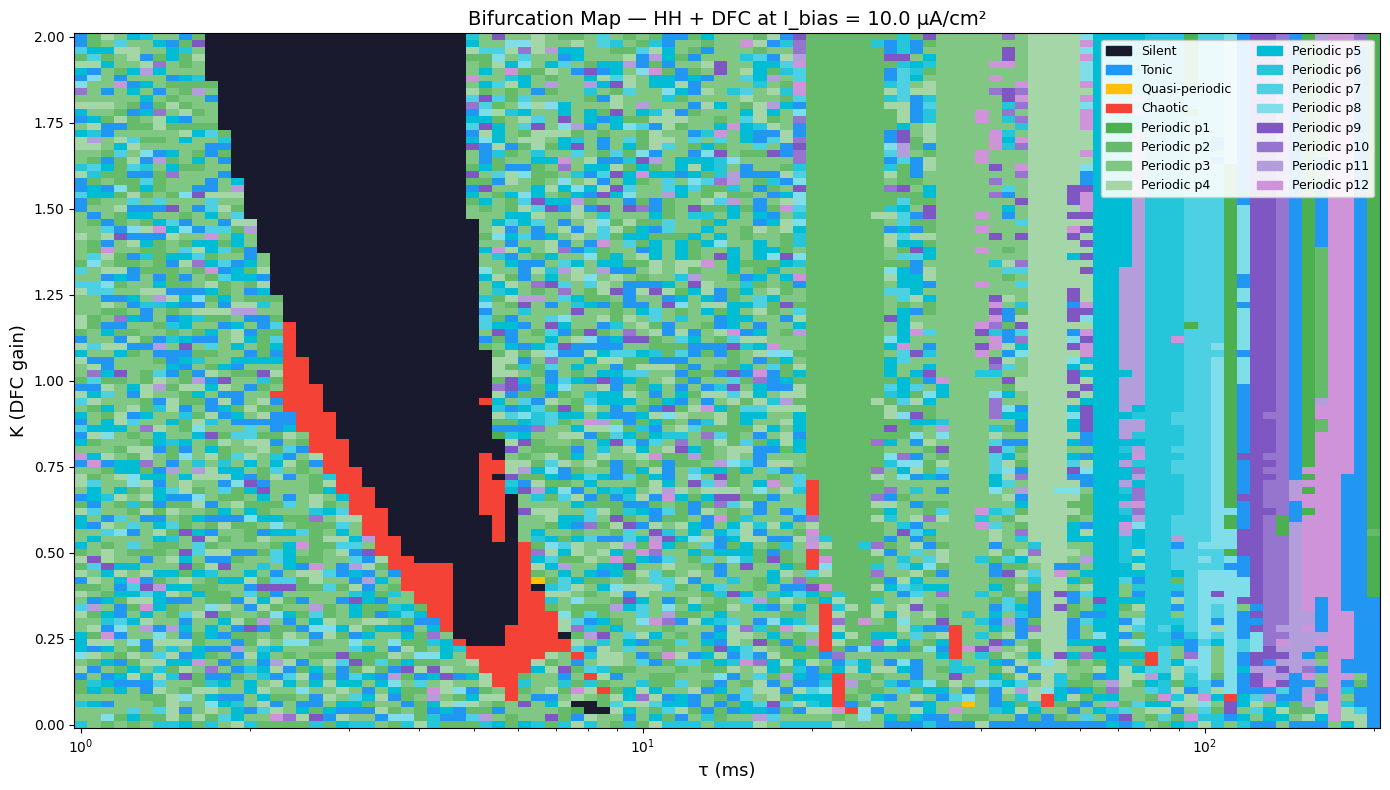

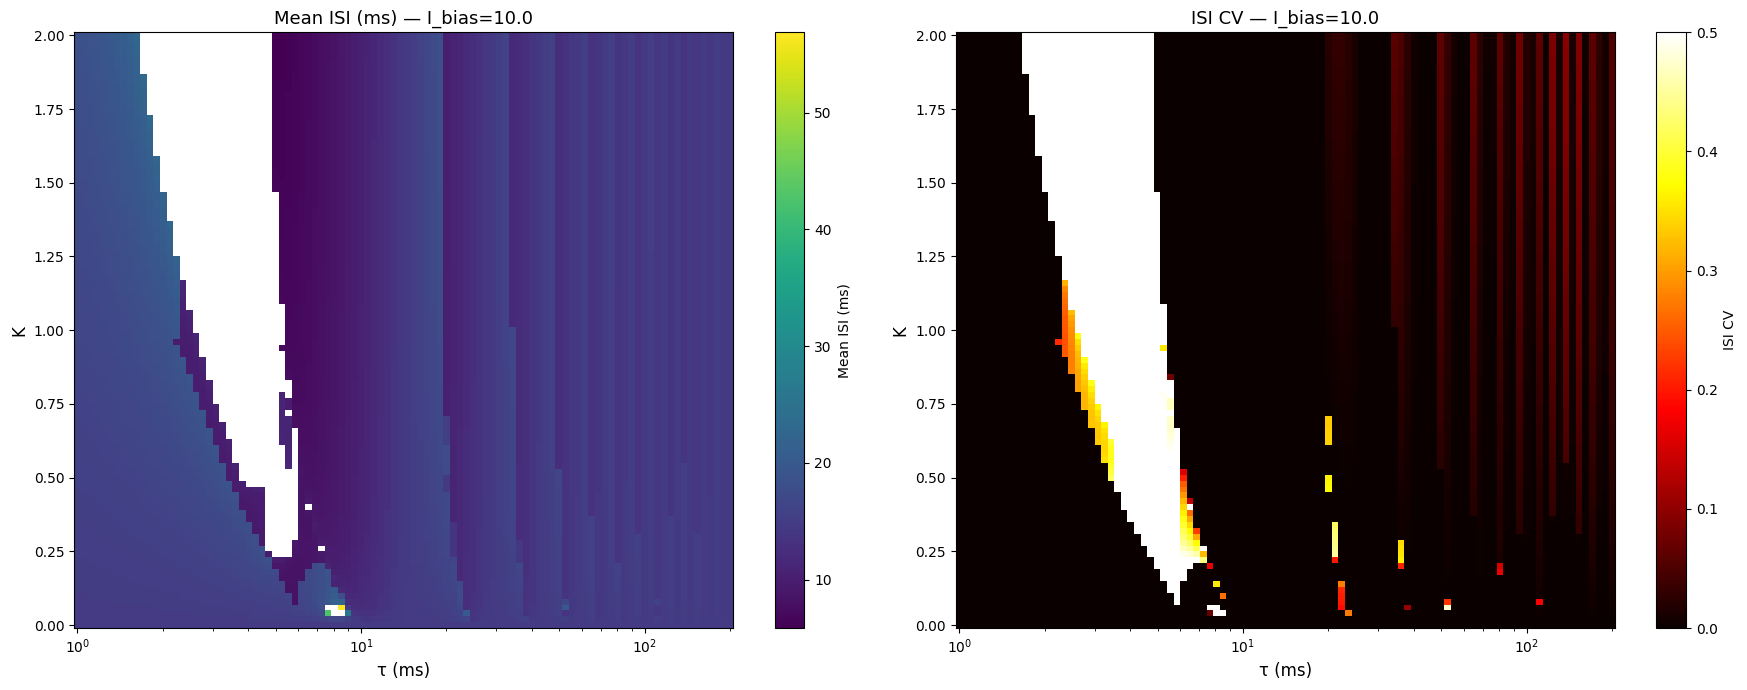


PHASE PS0-C — Orbit Fingerprint Clustering

Orbit clustering: 8677 periodic points
  Found 207 orbit clusters (threshold=2.0 ms)

ORBIT TYPE CATALOGUE — 207 distinct types
  ID   Category  PLen  ISI_mean  ISI_std   Period   FR(Hz)  Members     K*       τ*
--------------------------------------------------------------------------------
  82  burst_p12    12      5.91    0.000    70.87    169.2        1  1.880      5.0
  89  burst_p10    10      5.96    0.000    59.62    167.6        1  1.800      5.0
  41   burst_p7     7      6.12    0.126    43.26    162.0        8  1.960      5.5
  32   burst_p8     8      6.12    0.051    48.85    164.0        3  1.700      5.3
  31   burst_p9     9      6.12    0.057    54.76    164.4        6  1.740      5.3
  46   burst_p6     6      6.37    0.230    38.60    155.6        7  1.880      5.8
 187   burst_p5     5      6.44    0.291    32.24    155.2       31  1.300      5.3
  81  burst_p12    12      6.44    0.010    77.37    155.2        2  1.380

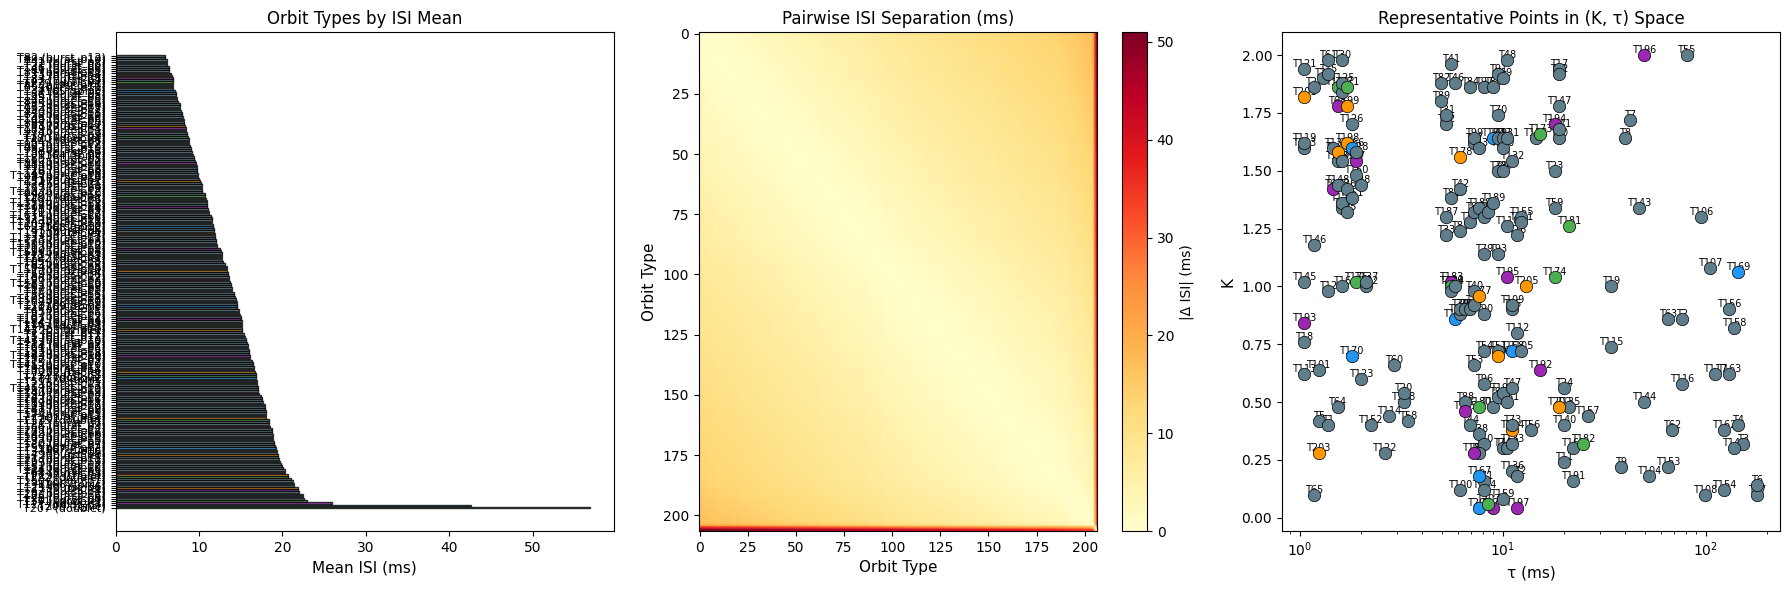


Orbit catalogue saved to /content/drive/My Drive/HHSMC/full_study/PS0_orbit_catalogue



GATE PS-G0 — ORBIT DIVERSITY ASSESSMENT

  Orbit types found: 207 (gate: ≥15) ✓ PASS
  Categories: 12 {'burst_p12': 22, 'burst_p10': 23, 'burst_p7': 21, 'burst_p8': 21, 'burst_p9': 23, 'burst_p6': 17, 'burst_p5': 15, 'triplet': 11, 'burst_p4': 13, 'doublet': 10, 'burst_p11': 23, 'tonic': 8} (gate: ≥3) ✓ PASS
  Separable pairs (Δ ISI > 2ms): 16457/21321
  Minimum ISI separation: 0.000 ms

  ✓✓✓ GATE PS-G0: PASS — Proceed to Phase PS1 ✓✓✓
  Orbit library has sufficient diversity for orbit-coded memory.

PS0 COMPLETE — ALL RESULTS SAVED
Output directory: /content/drive/My Drive/HHSMC/full_study/PS0_orbit_catalogue
Files:
  PS0_grid_data.npz        — Raw classification grid
  PS0_orbit_types.json     — Orbit type catalogue
  PS0_summary.json         — Sweep summary statistics
  gate_PS_G0_result.json   — Gate decision
  PS0_bifurcation_map.png  — (K, τ) dynamics heatmap
  PS0_isi_landscape.png    — IS

In [ ]:
if __name__ == '__main__' or True:  # Always run in Colab

    print("="*70)
    print("PS0 — DENSE ORBIT CATALOGUE")
    print("Option C: HH Delay-Directed Orbit Selection")
    print("="*70)

    # ---- Define parameter grid ----
    # Fixed I_bias from ExpF0v3 pilot (standard HH spiking regime)
    I_BIAS = 10.0  # μA/cm²

    # Dense (K, τ) grid — 10× denser than ExpF0v3
    K_range = np.arange(0.0, 2.02, 0.02)           # 101 values: 0.00, 0.02, ..., 2.00
    tau_range = np.geomspace(1.0, 200.0, 100)       # 100 values, log-spaced

    # Include K=0 as baseline (no DFC → natural tonic firing)
    print(f"\nGrid: {len(K_range)} × {len(tau_range)} "
          f"= {len(K_range)*len(tau_range)} points")
    print(f"I_bias = {I_BIAS:.1f} μA/cm²\n")

    # ==== DENSE SWEEP ====
    print("\n" + "="*50)
    print("PHASE PS0-A — Dense Parameter Sweep")
    print("="*50)
    (results_grid, class_grid, isi_mean_grid, cv_grid, fr_grid,
     summary) = run_dense_sweep(I_BIAS, K_range, tau_range,
                                 T_sim=3000.0, T_transient=500.0)

    # Save raw results
    np.savez_compressed(os.path.join(OUTPUT_DIR, 'PS0_grid_data.npz'),
                        class_grid=class_grid,
                        isi_mean_grid=isi_mean_grid,
                        cv_grid=cv_grid,
                        fr_grid=fr_grid,
                        K_range=K_range,
                        tau_range=tau_range)
    print(f"Grid data saved to {OUTPUT_DIR}")

    # ==== VISUALIZATION ====
    print("\n" + "="*50)
    print("PHASE PS0-B — Bifurcation Analysis")
    print("="*50)
    plot_bifurcation_map(class_grid, K_range, tau_range, I_BIAS,
                         save_dir=OUTPUT_DIR)
    plot_isi_landscape(isi_mean_grid, cv_grid, K_range, tau_range,
                       I_BIAS, save_dir=OUTPUT_DIR)

    # ==== ORBIT CLUSTERING ====
    print("\n" + "="*50)
    print("PHASE PS0-C — Orbit Fingerprint Clustering")
    print("="*50)
    orbit_types, orbit_assignments = cluster_orbits(
        results_grid, K_range, tau_range,
        min_isi_separation=2.0)

    plot_orbit_catalogue(orbit_types, save_dir=OUTPUT_DIR)

    # Save orbit catalogue
    with open(os.path.join(OUTPUT_DIR, 'PS0_orbit_types.json'), 'w') as f:
        json.dump(clean_for_json(orbit_types), f, indent=2)

    with open(os.path.join(OUTPUT_DIR, 'PS0_summary.json'), 'w') as f:
        json.dump(clean_for_json(summary), f, indent=2)

    print(f"\nOrbit catalogue saved to {OUTPUT_DIR}")

    # ==== GATE PS-G0 ====
    print("\n")
    gate_result = evaluate_gate_PS_G0(orbit_types, min_types=15, min_categories=3)

    with open(os.path.join(OUTPUT_DIR, 'gate_PS_G0_result.json'), 'w') as f:
        json.dump(clean_for_json(gate_result), f, indent=2)

    # ==== SECONDARY I_BIAS SWEEPS (if needed) ====
    if gate_result['decision'] == 'FAIL':
        print("\n" + "="*50)
        print("SECONDARY SWEEPS — Additional I_bias values")
        print("="*50)
        print("  Primary sweep at I_bias=10.0 insufficient.")
        print("  Running secondary sweeps at I_bias = 7.0, 8.5, 12.0, 15.0")
        print("  (Set SECONDARY_SWEEPS = True and re-run this cell)")

    # ==== FINAL SUMMARY ====
    print(f"\n{'='*70}")
    print(f"PS0 COMPLETE — ALL RESULTS SAVED")
    print(f"{'='*70}")
    print(f"Output directory: {OUTPUT_DIR}")
    print(f"Files:")
    print(f"  PS0_grid_data.npz        — Raw classification grid")
    print(f"  PS0_orbit_types.json     — Orbit type catalogue")
    print(f"  PS0_summary.json         — Sweep summary statistics")
    print(f"  gate_PS_G0_result.json   — Gate decision")
    print(f"  PS0_bifurcation_map.png  — (K, τ) dynamics heatmap")
    print(f"  PS0_isi_landscape.png    — ISI mean and CV landscapes")
    print(f"  PS0_orbit_catalogue.png  — Orbit types visualization")
    print(f"\nGate PS-G0: {gate_result['decision']}")
    if gate_result['decision'] == 'PASS':
        print(f"  → PROCEED TO PHASE PS1 (Write Protocol & Settling Time)")
    else:
        print(f"  → Run secondary I_bias sweeps or adjust clustering threshold")